In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [22]:
DATA_PATH = "../data/processed/apex_enthusiast_cars_clean.csv"

df = pd.read_csv(DATA_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()

Rows: 10480
Columns: 40


,source_row_id,project_scope,manufacturer,model,model_family,generation,generation_quality_flag,year,price,price_drop,mileage,mileage_quality_flag,transmission,transmission_type,transmission_group,transmission_quality_flag,drivetrain,drivetrain_group,drivetrain_quality_flag,engine,engine_displacement_l,engine_cylinders,fuel_type,fuel_group,fuel_quality_flag,mpg,city_mpg,highway_mpg,combined_mpg_simple,accidents_or_damage,accident_history,one_owner,one_owner_status,personal_use_only,personal_use_status,exterior_color,interior_color,seller_rating,driver_rating,driver_reviews_num
0,9114,Core,Audi,RS 5 2.9T,RS5,B9,Mapped,2022,"81,591.00","2,580.00","12,413.00",Valid,Automatic,Automatic,Automatic,Parsed,All-wheel Drive,AWD,Parsed,2.9L V6 24V GDI DOHC Twin Turbo,2.90,6.00,Gasoline,Gasoline,Parsed,NaN,NaN,NaN,NaN,0.00,No Accident/Damage Reported,1.00,One Owner,1.00,Personal Use Only,Nardo Gray,Black / Gray,4.60,NaN,0.00
1,9115,Core,Audi,RS 5 2.9T,RS5,B9,Mapped,2019,"57,998.00","1,000.00","37,686.00",Valid,8-Speed Automatic,Automatic,Automatic,Parsed,All-wheel Drive,AWD,Parsed,2.9L V6 24V GDI DOHC Twin Turbo,2.90,6.00,Gasoline,Gasoline,Parsed,17-26,17.00,26.00,21.50,0.00,No Accident/Damage Reported,1.00,One Owner,1.00,Personal Use Only,Mythos Black Metallic,Black / Gray,3.50,4.80,11.00
2,9116,Core,Audi,RS 5 4.2,RS5,B8.5,Mapped,2013,"32,950.00",NaN,"71,375.00",Valid,7-Speed Automatic with Auto-Shift,Automatic,Automatic,Parsed,All-wheel Drive,AWD,Parsed,4.2L V8 32V GDI DOHC,4.20,8.00,Gasoline,Gasoline,Parsed,16-23,16.00,23.00,19.50,1.00,Accident/Damage Reported,0.00,Not One Owner,1.00,Personal Use Only,NaN,NaN,2.80,4.40,15.00
3,9117,Core,Audi,RS 5 2.9T,RS5,B9,Mapped,2019,"60,777.00","1,220.00","42,592.00",Valid,8-Speed Automatic,Automatic,Automatic,Parsed,All-wheel Drive,AWD,Parsed,2.9L V6 24V GDI DOHC Twin Turbo,2.90,6.00,Gasoline,Gasoline,Parsed,17-26,17.00,26.00,21.50,0.00,No Accident/Damage Reported,1.00,One Owner,1.00,Personal Use Only,Navarra Blue Metallic,Lunar Silver,4.50,4.80,11.00
4,9118,Core,Audi,RS 5 4.2,RS5,B8.5,Mapped,2014,"38,850.00",NaN,"78,730.00",Valid,Automatic,Automatic,Automatic,Parsed,All-wheel Drive,AWD,Parsed,"4.2L V-8 gasoline direct injection, DOHC, vari...",4.20,8.00,Gasoline,Gasoline,Parsed,16-0,NaN,NaN,NaN,0.00,No Accident/Damage Reported,0.00,Not One Owner,0.00,Not Personal Use Only,WHITE,NaN,NaN,4.80,15.00


In [23]:
manufacturer_summary = (
    df.groupby("manufacturer")
      .agg(
          listings=("source_row_id", "count"),
          median_price=("price", "median"),
          median_mileage=("mileage", "median")
      )
      .sort_values("listings", ascending=False)
      .reset_index()
)

manufacturer_summary

,manufacturer,listings,median_price,median_mileage
0,Porsche,4014,"104,894.00","21,223.50"
1,Chevrolet,2688,"59,992.50","16,123.00"
2,BMW,1643,"60,500.00","31,006.50"
3,Mercedes-Benz,1171,"82,597.00","24,985.50"
4,Audi,402,"59,337.50","30,171.50"
5,Toyota,271,"54,251.00","9,650.00"
6,Nissan,154,"94,941.50","24,451.50"
7,Cadillac,137,"71,999.00","3,216.00"


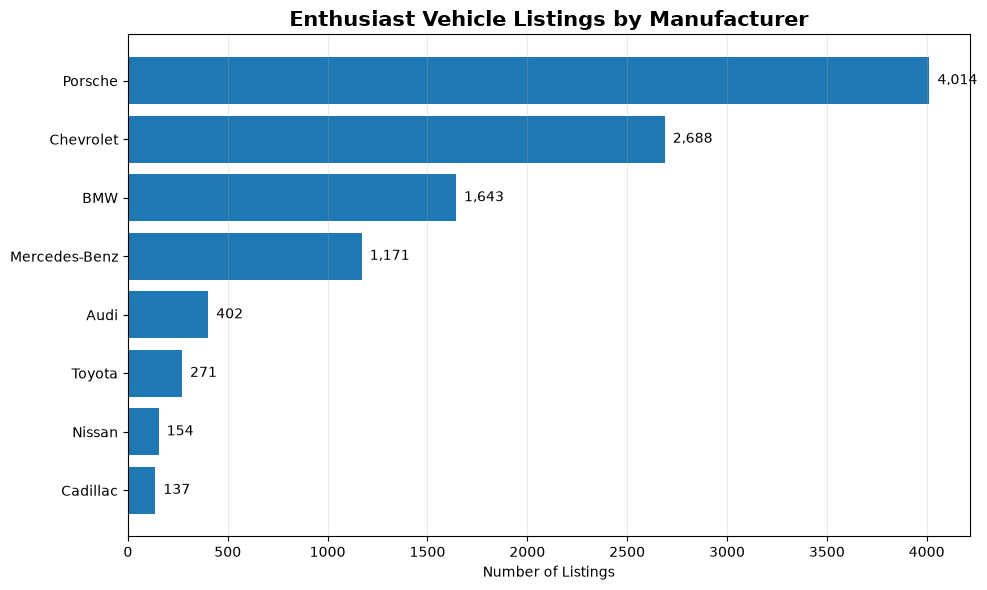

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    manufacturer_summary["manufacturer"],
    manufacturer_summary["listings"]
)

ax.invert_yaxis()

ax.set_title(
    "Enthusiast Vehicle Listings by Manufacturer",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Number of Listings")
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(manufacturer_summary["listings"]):
    ax.text(
        value + 40,
        i,
        f"{value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

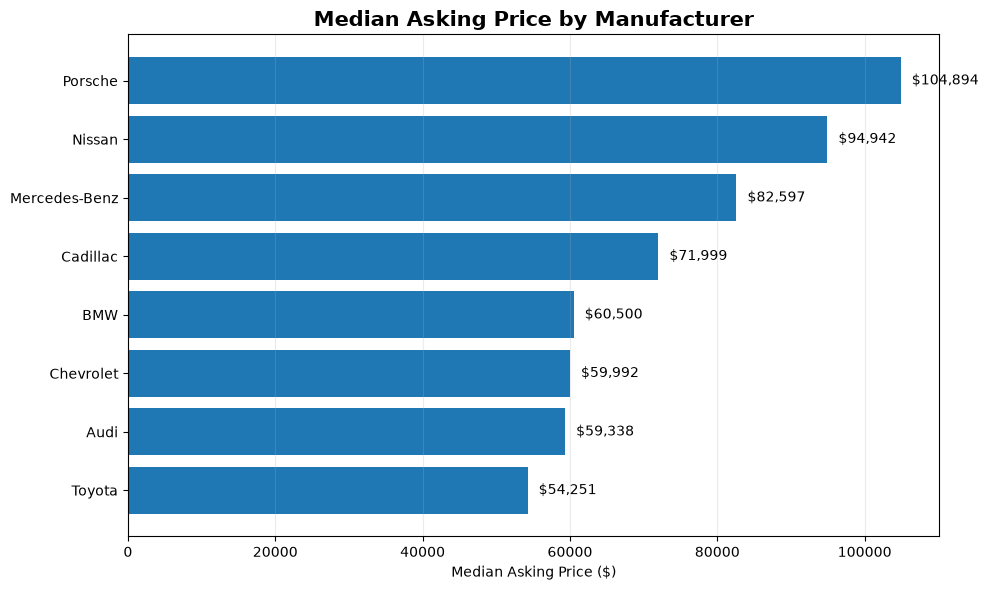

In [25]:
price_by_manufacturer = (
    manufacturer_summary
    .sort_values("median_price", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    price_by_manufacturer["manufacturer"],
    price_by_manufacturer["median_price"]
)

ax.invert_yaxis()

ax.set_title(
    "Median Asking Price by Manufacturer",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Median Asking Price ($)")
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(price_by_manufacturer["median_price"]):
    ax.text(
        value + 1500,
        i,
        f"${value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [26]:
model_family_summary = (
    df.groupby(
        ["manufacturer", "model_family", "project_scope"],
        as_index=False
    )
    .agg(
        listings=("source_row_id", "count"),
        median_price=("price", "median"),
        median_mileage=("mileage", "median")
    )
    .sort_values("listings", ascending=False)
    .reset_index(drop=True)
)

model_family_summary

,manufacturer,model_family,project_scope,listings,median_price,median_mileage
0,Porsche,911,Core,2962,"125,000.00","19,023.00"
1,Chevrolet,Corvette C7,Core,984,"56,659.50","20,322.50"
2,Chevrolet,Corvette C8,Core,914,"91,998.00","2,588.00"
3,Porsche,Boxster / 718 Roadster,Supporting,626,"42,995.00","36,850.00"
4,BMW,M4,Core,565,"63,677.00","20,008.00"
5,BMW,M3,Core,527,"48,900.00","50,633.00"
6,Chevrolet,Corvette C6,Core,515,"31,547.00","40,138.00"
7,Porsche,Cayman / 718 Coupe,Core,426,"59,995.00","23,129.50"
8,BMW,M5,Supporting,394,"73,934.00","32,931.50"
9,Mercedes-Benz,C63,Core,342,"59,000.00","35,675.50"


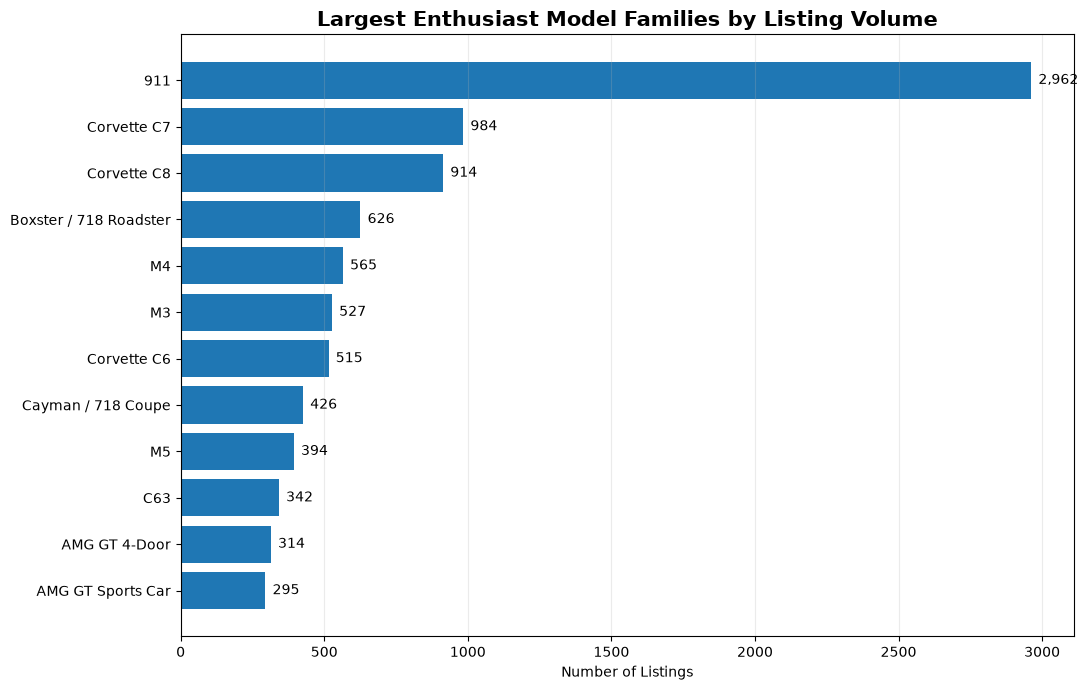

In [27]:
top_model_families = (
    model_family_summary
    .head(12)
    .copy()
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    top_model_families["model_family"],
    top_model_families["listings"]
)

ax.invert_yaxis()

ax.set_title(
    "Largest Enthusiast Model Families by Listing Volume",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Number of Listings")
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(top_model_families["listings"]):
    ax.text(
        value + 25,
        i,
        f"{value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [28]:
generation_df = df[
    df["generation_quality_flag"] == "Mapped"
].copy()

# Analytical lineage used for cross-generation comparisons
generation_df["analysis_lineage"] = np.where(
    generation_df["model_family"].str.startswith("Corvette C"),
    "Corvette",
    generation_df["model_family"]
)

generation_summary = (
    generation_df
    .groupby(
        ["manufacturer", "analysis_lineage", "generation"],
        as_index=False
    )
    .agg(
        listings=("source_row_id", "count"),
        median_price=("price", "median"),
        earliest_year=("year", "min"),
        latest_year=("year", "max")
    )
)

# Keep reasonably represented generations
generation_summary = (
    generation_summary[
        generation_summary["listings"] >= 20
    ]
    .sort_values(
        ["analysis_lineage", "earliest_year"]
    )
    .reset_index(drop=True)
)

generation_summary[
    generation_summary["analysis_lineage"].isin(
        ["M3", "Corvette", "911", "C63"]
    )
]

,manufacturer,analysis_lineage,generation,listings,median_price,earliest_year,latest_year
0,Porsche,911,Classic / Pre-G,22,"74,974.50",1965,1973
1,Porsche,911,G-Series,69,"84,980.00",1974,1988
2,Porsche,911,964,34,"118,700.00",1989,1993
3,Porsche,911,993,68,"119,995.00",1994,1998
4,Porsche,911,996,258,"34,995.00",1999,2004
5,Porsche,911,997,399,"63,495.00",2005,2011
6,Porsche,911,991,1223,"126,993.00",2013,2019
7,Porsche,911,992,809,"173,992.00",2020,2023
14,Mercedes-Benz,C63,W204/C204,33,"30,995.00",2008,2014
15,Mercedes-Benz,C63,W205/C205,309,"59,988.00",2015,2021


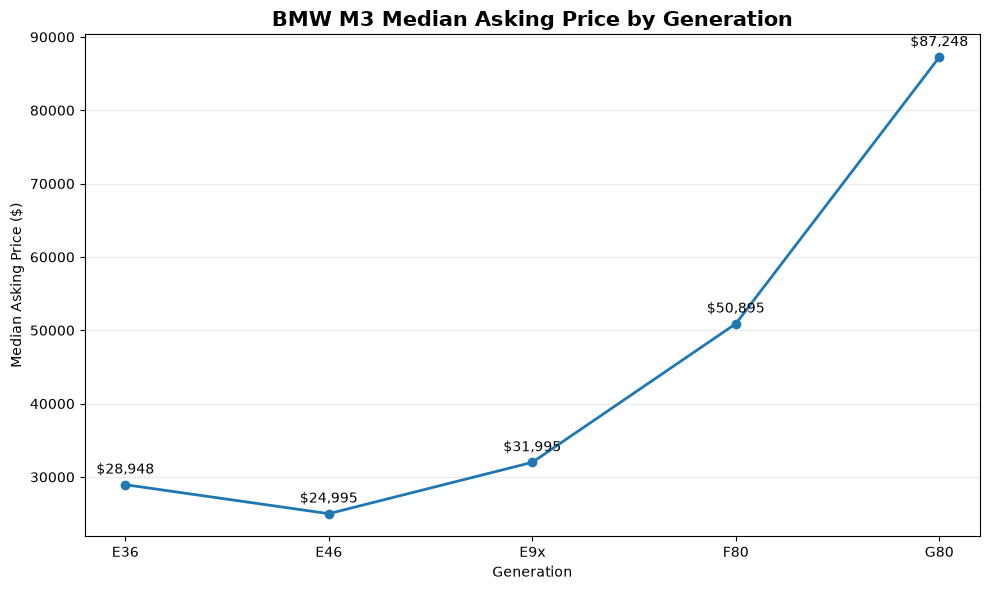

In [29]:
m3_generations = (
    generation_summary[
        generation_summary["analysis_lineage"] == "M3"
    ]
    .sort_values("earliest_year")
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    m3_generations["generation"],
    m3_generations["median_price"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "BMW M3 Median Asking Price by Generation",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Generation")
ax.set_ylabel("Median Asking Price ($)")

ax.grid(axis="y", alpha=0.25)

for x, y in zip(
    m3_generations["generation"],
    m3_generations["median_price"]
):
    ax.annotate(
        f"${y:,.0f}",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.tight_layout()
plt.show()

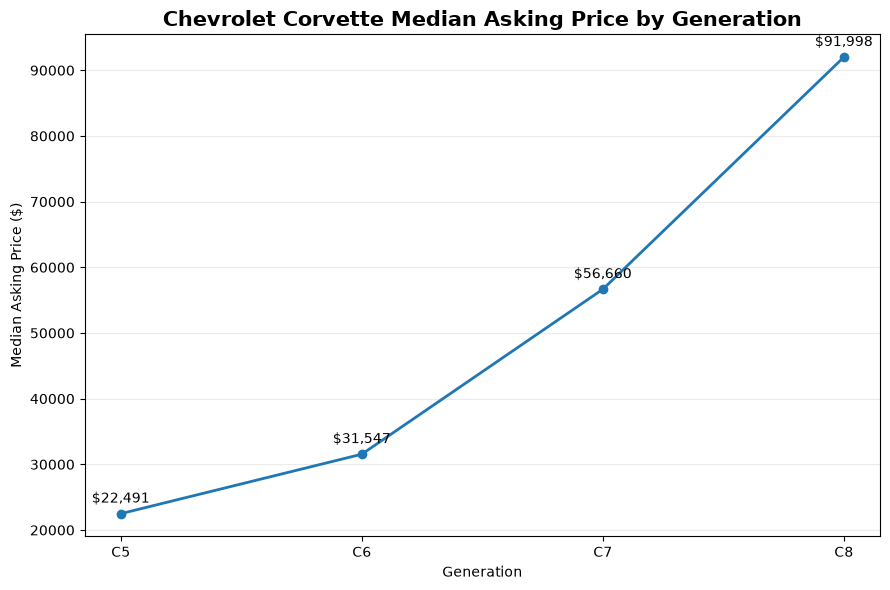

In [30]:
corvette_generations = (
    generation_summary[
        generation_summary["analysis_lineage"] == "Corvette"
    ]
    .sort_values("earliest_year")
    .copy()
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    corvette_generations["generation"],
    corvette_generations["median_price"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Chevrolet Corvette Median Asking Price by Generation",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Generation")
ax.set_ylabel("Median Asking Price ($)")

ax.grid(axis="y", alpha=0.25)

for x, y in zip(
    corvette_generations["generation"],
    corvette_generations["median_price"]
):
    ax.annotate(
        f"${y:,.0f}",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.tight_layout()
plt.show()

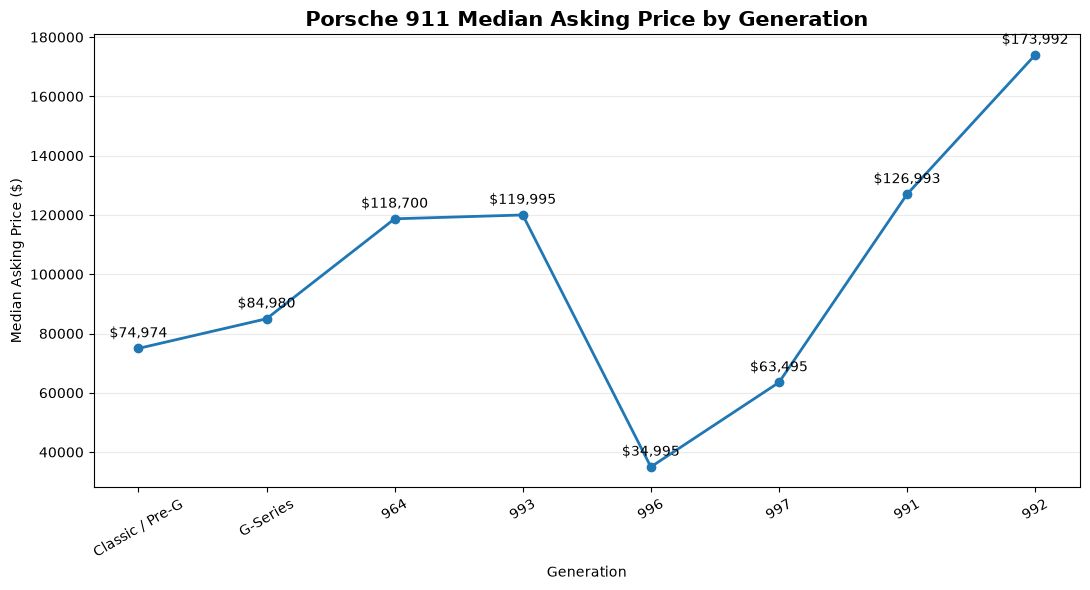

In [47]:
porsche_911_generations = (
    generation_summary[
        generation_summary["analysis_lineage"] == "911"
    ]
    .sort_values("earliest_year")
    .copy()
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    porsche_911_generations["generation"],
    porsche_911_generations["median_price"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Porsche 911 Median Asking Price by Generation",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Generation")
ax.set_ylabel("Median Asking Price ($)")

ax.grid(axis="y", alpha=0.25)

for x, y in zip(
    porsche_911_generations["generation"],
    porsche_911_generations["median_price"]
):
    ax.annotate(
        f"${y:,.0f}",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "911_generation_prices.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [32]:
# Manual vs automatic price comparison within matched peer groups

transmission_df = df[
    (df["generation_quality_flag"] == "Mapped") &
    (df["transmission_quality_flag"] != "Source inconsistency") &
    (df["transmission_group"].isin(["Manual", "Automatic"])) &
    (df["mileage"] > 0)
].copy()

# Same mileage bands used in SQL
transmission_df["mileage_band"] = pd.cut(
    transmission_df["mileage"],
    bins=[0, 10000, 25000, 50000, 75000, 100000, np.inf],
    labels=[
        "00-09k",
        "10-24k",
        "25-49k",
        "50-74k",
        "75-99k",
        "100k+"
    ],
    right=False
)

peer_cols = [
    "manufacturer",
    "model",
    "generation",
    "year",
    "mileage_band"
]

comparison_rows = []

for peer_key, group in transmission_df.groupby(
    peer_cols,
    observed=True
):
    manual = group[group["transmission_group"] == "Manual"]
    automatic = group[group["transmission_group"] == "Automatic"]

    # Same minimum sample requirement used in SQL
    if len(manual) < 3 or len(automatic) < 3:
        continue

    q1 = group["price"].quantile(0.25)
    median_price = group["price"].median()
    q3 = group["price"].quantile(0.75)

    peer_dispersion_pct = (
        (q3 - q1) / median_price * 100
    )

    # Same 35% dispersion safeguard used in SQL
    if peer_dispersion_pct > 35:
        continue

    manual_median = manual["price"].median()
    automatic_median = automatic["price"].median()

    manual_premium_pct = (
        (manual_median - automatic_median)
        / automatic_median
        * 100
    )

    comparison_rows.append({
        "manufacturer": peer_key[0],
        "model": peer_key[1],
        "generation": peer_key[2],
        "year": peer_key[3],
        "mileage_band": peer_key[4],
        "manual_count": len(manual),
        "automatic_count": len(automatic),
        "manual_premium_pct": manual_premium_pct
    })

transmission_peer_summary = pd.DataFrame(comparison_rows)

transmission_model_summary = (
    transmission_peer_summary
    .groupby(
        ["manufacturer", "model", "generation"],
        as_index=False
    )
    .agg(
        matched_peer_groups=("manual_premium_pct", "count"),
        manual_listings=("manual_count", "sum"),
        automatic_listings=("automatic_count", "sum"),
        median_manual_premium_pct=("manual_premium_pct", "median")
    )
)

transmission_model_summary = (
    transmission_model_summary[
        transmission_model_summary["matched_peer_groups"] >= 3
    ]
    .sort_values(
        "median_manual_premium_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

transmission_model_summary

,manufacturer,model,generation,matched_peer_groups,manual_listings,automatic_listings,median_manual_premium_pct
0,Porsche,911 Carrera S,991,3,9,34,8.11
1,Porsche,Cayman S,987 Cayman,4,17,13,4.74
2,Chevrolet,Corvette,C6,4,15,29,4.18
3,BMW,M3 Base,F80,9,36,71,3.98
4,Chevrolet,Corvette Z06,C7,6,26,87,1.69
5,BMW,M4 Base,F82/F83,9,46,153,1.33
6,BMW,M2 Competition,F87,4,19,17,1.11
7,Chevrolet,Corvette Stingray Base,C7,3,13,35,1.07
8,Chevrolet,Corvette Stingray Z51,C7,9,62,119,-0.14
9,Chevrolet,Corvette Stingray,C7,7,33,108,-1.55


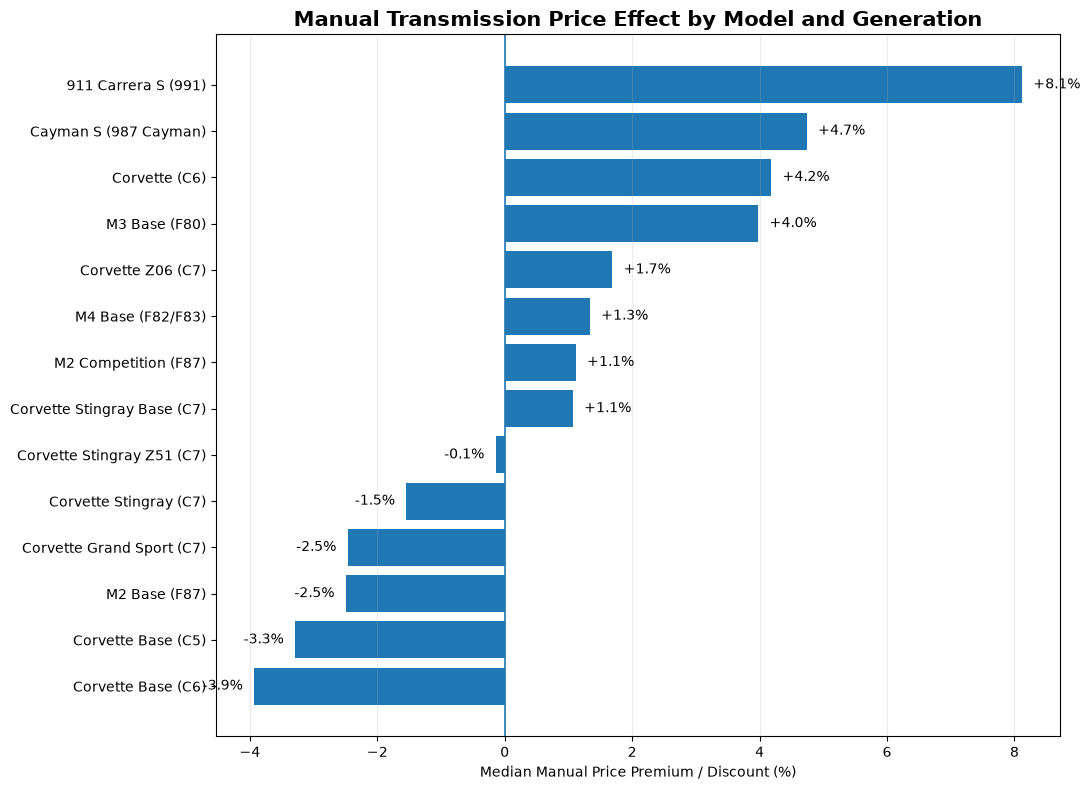

In [49]:
plot_df = (
    transmission_model_summary
    .sort_values(
        "median_manual_premium_pct",
        ascending=True
    )
    .copy()
)

plot_df["label"] = (
    plot_df["model"]
    + " (" + plot_df["generation"] + ")"
)

fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(
    plot_df["label"],
    plot_df["median_manual_premium_pct"]
)

ax.axvline(
    0,
    linewidth=1.2
)

ax.set_title(
    "Manual Transmission Price Effect by Model and Generation",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Median Manual Price Premium / Discount (%)")
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(
    plot_df["median_manual_premium_pct"]
):
    offset = 0.18 if value >= 0 else -0.18

    ax.text(
        value + offset,
        i,
        f"{value:+.1f}%",
        va="center",
        ha="left" if value >= 0 else "right"
    )

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "manual_transmission_effect.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [34]:
# Accident-history price effect within matched peer groups

accident_df = df[
    (df["generation_quality_flag"] == "Mapped") &
    (df["mileage"] > 0) &
    (df["accident_history"].isin([
        "Accident/Damage Reported",
        "No Accident/Damage Reported"
    ]))
].copy()

accident_df["mileage_band"] = pd.cut(
    accident_df["mileage"],
    bins=[0, 10000, 25000, 50000, 75000, 100000, np.inf],
    labels=[
        "00-09k",
        "10-24k",
        "25-49k",
        "50-74k",
        "75-99k",
        "100k+"
    ],
    right=False
)

peer_cols = [
    "manufacturer",
    "model",
    "generation",
    "year",
    "mileage_band"
]

comparison_rows = []

for peer_key, group in accident_df.groupby(
    peer_cols,
    observed=True
):
    accident = group[
        group["accident_history"] == "Accident/Damage Reported"
    ]

    clean = group[
        group["accident_history"] == "No Accident/Damage Reported"
    ]

    # Same sample threshold used in SQL
    if len(accident) < 3 or len(clean) < 3:
        continue

    q1 = group["price"].quantile(0.25)
    median_price = group["price"].median()
    q3 = group["price"].quantile(0.75)

    peer_dispersion_pct = (
        (q3 - q1) / median_price * 100
    )

    # Same 35% peer-dispersion safeguard
    if peer_dispersion_pct > 35:
        continue

    accident_median = accident["price"].median()
    clean_median = clean["price"].median()

    accident_effect_pct = (
        (accident_median - clean_median)
        / clean_median
        * 100
    )

    comparison_rows.append({
        "manufacturer": peer_key[0],
        "model": peer_key[1],
        "generation": peer_key[2],
        "year": peer_key[3],
        "mileage_band": peer_key[4],
        "accident_count": len(accident),
        "clean_count": len(clean),
        "accident_price_effect_pct": accident_effect_pct
    })

accident_peer_summary = pd.DataFrame(comparison_rows)

accident_model_summary = (
    accident_peer_summary
    .groupby(
        ["manufacturer", "model", "generation"],
        as_index=False
    )
    .agg(
        matched_peer_groups=("accident_price_effect_pct", "count"),
        accident_history_listings=("accident_count", "sum"),
        clean_history_listings=("clean_count", "sum"),
        median_accident_price_effect_pct=(
            "accident_price_effect_pct",
            "median"
        )
    )
)

accident_model_summary = (
    accident_model_summary[
        accident_model_summary["matched_peer_groups"] >= 3
    ]
    .sort_values(
        "median_accident_price_effect_pct"
    )
    .reset_index(drop=True)
)

accident_model_summary

,manufacturer,model,generation,matched_peer_groups,accident_history_listings,clean_history_listings,median_accident_price_effect_pct
0,Porsche,911 Carrera,991,3,13,28,-10.73
1,Chevrolet,Corvette Base,C5,3,10,25,-8.29
2,Chevrolet,Corvette,C6,4,17,25,-6.97
3,Chevrolet,Corvette Stingray,C7,6,29,106,-5.16
4,Chevrolet,Corvette Base,C6,5,26,76,-4.37
5,BMW,M5 Base,F90,4,22,30,-4.27
6,Mercedes-Benz,AMG E 63 S 4MATIC,W213/S213,3,16,42,-3.92
7,Chevrolet,Corvette Z06,C7,3,10,58,-3.68
8,BMW,M4 Base,F82/F83,14,82,150,-3.64
9,BMW,M3 Base,F80,10,53,56,-3.63


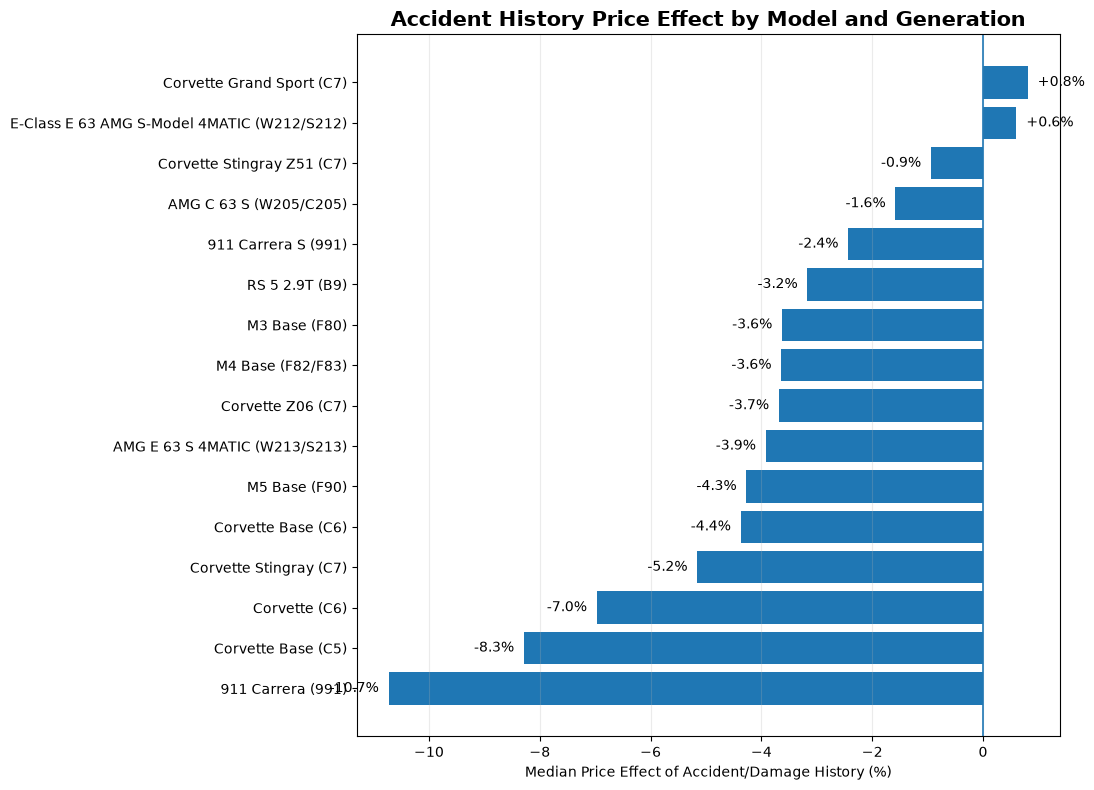

In [51]:
plot_df = (
    accident_model_summary
    .sort_values(
        "median_accident_price_effect_pct",
        ascending=True
    )
    .copy()
)

plot_df["label"] = (
    plot_df["model"]
    + " (" + plot_df["generation"] + ")"
)

fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(
    plot_df["label"],
    plot_df["median_accident_price_effect_pct"]
)

ax.axvline(
    0,
    linewidth=1.2
)

ax.set_title(
    "Accident History Price Effect by Model and Generation",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Median Price Effect of Accident/Damage History (%)")
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(
    plot_df["median_accident_price_effect_pct"]
):
    offset = 0.18 if value >= 0 else -0.18

    ax.text(
        value + offset,
        i,
        f"{value:+.1f}%",
        va="center",
        ha="left" if value >= 0 else "right"
    )

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "accident_history_effect.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [36]:
def matched_history_summary(
    data,
    status_col,
    positive_label,
    negative_label
):
    analysis = data[
        (data["generation_quality_flag"] == "Mapped") &
        (data["mileage"] > 0) &
        (data[status_col].isin([
            positive_label,
            negative_label
        ]))
    ].copy()

    analysis["mileage_band"] = pd.cut(
        analysis["mileage"],
        bins=[
            0,
            10000,
            25000,
            50000,
            75000,
            100000,
            np.inf
        ],
        labels=[
            "00-09k",
            "10-24k",
            "25-49k",
            "50-74k",
            "75-99k",
            "100k+"
        ],
        right=False
    )

    peer_cols = [
        "manufacturer",
        "model",
        "generation",
        "year",
        "mileage_band"
    ]

    effects = []

    for _, group in analysis.groupby(
        peer_cols,
        observed=True
    ):
        positive = group[
            group[status_col] == positive_label
        ]

        negative = group[
            group[status_col] == negative_label
        ]

        if len(positive) < 3 or len(negative) < 3:
            continue

        q1 = group["price"].quantile(0.25)
        median_price = group["price"].median()
        q3 = group["price"].quantile(0.75)

        dispersion_pct = (
            (q3 - q1) / median_price * 100
        )

        if dispersion_pct > 35:
            continue

        positive_median = positive["price"].median()
        negative_median = negative["price"].median()

        effect_pct = (
            (positive_median - negative_median)
            / negative_median
            * 100
        )

        effects.append({
            "effect_pct": effect_pct,
            "listings": len(positive) + len(negative)
        })

    result = pd.DataFrame(effects)

    return {
        "qualified_groups": len(result),
        "qualified_listings": result["listings"].sum(),
        "median_effect_pct": result["effect_pct"].median(),
        "groups_with_premium": (result["effect_pct"] > 0).sum(),
        "groups_with_discount": (result["effect_pct"] < 0).sum(),
        "pct_groups_with_premium":
            (result["effect_pct"] > 0).mean() * 100
    }


one_owner_result = matched_history_summary(
    df,
    "one_owner_status",
    "One Owner",
    "Not One Owner"
)

personal_use_result = matched_history_summary(
    df,
    "personal_use_status",
    "Personal Use Only",
    "Not Personal Use Only"
)

history_summary = pd.DataFrame([
    {
        "attribute": "One Owner",
        **one_owner_result
    },
    {
        "attribute": "Personal Use Only",
        **personal_use_result
    }
])

history_summary

,attribute,qualified_groups,qualified_listings,median_effect_pct,groups_with_premium,groups_with_discount,pct_groups_with_premium
0,One Owner,201,3863,0.39,110,91,54.73
1,Personal Use Only,147,3202,-0.73,66,81,44.90


In [37]:
accident_overall = {
    "attribute": "Accident/Damage Reported",
    "qualified_groups": len(accident_peer_summary),
    "qualified_listings": (
        accident_peer_summary["accident_count"]
        + accident_peer_summary["clean_count"]
    ).sum(),
    "median_effect_pct":
        accident_peer_summary["accident_price_effect_pct"].median()
}

history_effect_comparison = pd.DataFrame([
    accident_overall,
    {
        "attribute": "One Owner",
        "qualified_groups": one_owner_result["qualified_groups"],
        "qualified_listings": one_owner_result["qualified_listings"],
        "median_effect_pct": one_owner_result["median_effect_pct"]
    },
    {
        "attribute": "Personal Use Only",
        "qualified_groups": personal_use_result["qualified_groups"],
        "qualified_listings": personal_use_result["qualified_listings"],
        "median_effect_pct": personal_use_result["median_effect_pct"]
    }
])

history_effect_comparison

,attribute,qualified_groups,qualified_listings,median_effect_pct
0,Accident/Damage Reported,127,2076,-4.00
1,One Owner,201,3863,0.39
2,Personal Use Only,147,3202,-0.73


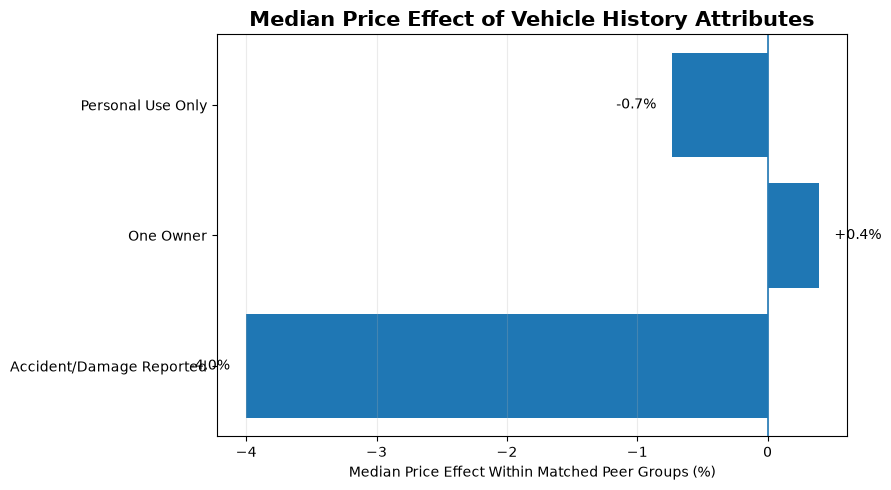

In [53]:
plot_df = history_effect_comparison.copy()

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    plot_df["attribute"],
    plot_df["median_effect_pct"]
)

ax.axvline(
    0,
    linewidth=1.2
)

ax.set_title(
    "Median Price Effect of Vehicle History Attributes",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Median Price Effect Within Matched Peer Groups (%)")
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(plot_df["median_effect_pct"]):
    offset = 0.12 if value >= 0 else -0.12

    ax.text(
        value + offset,
        i,
        f"{value:+.1f}%",
        va="center",
        ha="left" if value >= 0 else "right"
    )

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "vehicle_history_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [40]:
# Mileage-adjusted age-price retention analysis
#
# Same methodology as SQL:
# - mapped generations only
# - positive price and mileage
# - at least 50 listings and 4 model years overall
# - at least 3 listings per year/mileage-band cell
# - at least 3 model years per mileage-band regression
# - R² >= 0.70
# - at least 2 reliable mileage bands per model/generation

retention_df = df[
    (df["generation_quality_flag"] == "Mapped") &
    (df["price"] > 0) &
    (df["mileage"] > 0)
].copy()

retention_df["mileage_band"] = pd.cut(
    retention_df["mileage"],
    bins=[0, 10000, 25000, 50000, 75000, 100000, np.inf],
    labels=[
        "00-09k",
        "10-24k",
        "25-49k",
        "50-74k",
        "75-99k",
        "100k+"
    ],
    right=False
)

# Overall model/generation coverage
overall_coverage = (
    retention_df
    .groupby(
        ["manufacturer", "model", "generation"],
        observed=True
    )
    .agg(
        overall_listings=("source_row_id", "count"),
        overall_model_years=("year", "nunique")
    )
    .reset_index()
)

overall_coverage = overall_coverage[
    (overall_coverage["overall_listings"] >= 50) &
    (overall_coverage["overall_model_years"] >= 4)
].copy()

# Median price for each year within each mileage band
year_band_stats = (
    retention_df
    .groupby(
        [
            "manufacturer",
            "model",
            "generation",
            "mileage_band",
            "year"
        ],
        observed=True
    )
    .agg(
        listings=("source_row_id", "count"),
        median_price=("price", "median")
    )
    .reset_index()
)

year_band_stats = year_band_stats[
    year_band_stats["listings"] >= 3
].copy()

# Run a separate year-price regression in each mileage band
regression_rows = []

band_cols = [
    "manufacturer",
    "model",
    "generation",
    "mileage_band"
]

for band_key, group in year_band_stats.groupby(
    band_cols,
    observed=True
):
    if group["year"].nunique() < 3:
        continue

    x = group["year"].astype(float).to_numpy()
    y = group["median_price"].astype(float).to_numpy()

    slope, intercept = np.polyfit(x, y, 1)

    correlation = np.corrcoef(x, y)[0, 1]
    r2 = correlation ** 2

    band_median_price = group["median_price"].median()

    annual_age_price_gap_pct = (
        slope / band_median_price * 100
    )

    regression_rows.append({
        "manufacturer": band_key[0],
        "model": band_key[1],
        "generation": band_key[2],
        "mileage_band": band_key[3],
        "model_years": group["year"].nunique(),
        "listings": group["listings"].sum(),
        "price_year_r2": r2,
        "annual_age_price_gap_pct":
            annual_age_price_gap_pct
    })

band_regressions = pd.DataFrame(regression_rows)

# Keep only reliable within-mileage-band relationships
reliable_bands = band_regressions[
    band_regressions["price_year_r2"] >= 0.70
].copy()

# Summarize to model/generation level
retention_summary = (
    reliable_bands
    .groupby(
        ["manufacturer", "model", "generation"],
        as_index=False
    )
    .agg(
        reliable_mileage_bands=("mileage_band", "count"),
        listings_in_reliable_bands=("listings", "sum"),
        median_annual_age_price_gap_pct=(
            "annual_age_price_gap_pct",
            "median"
        ),
        median_band_r2=("price_year_r2", "median"),
        lowest_band_age_price_gap_pct=(
            "annual_age_price_gap_pct",
            "min"
        ),
        highest_band_age_price_gap_pct=(
            "annual_age_price_gap_pct",
            "max"
        )
    )
)

retention_summary = retention_summary.merge(
    overall_coverage,
    on=["manufacturer", "model", "generation"],
    how="inner"
)

retention_summary = (
    retention_summary[
        retention_summary["reliable_mileage_bands"] >= 2
    ]
    .sort_values(
        "median_annual_age_price_gap_pct"
    )
    .reset_index(drop=True)
)

retention_summary[
    [
        "manufacturer",
        "model",
        "generation",
        "overall_model_years",
        "overall_listings",
        "reliable_mileage_bands",
        "median_annual_age_price_gap_pct",
        "median_band_r2"
    ]
]

,manufacturer,model,generation,overall_model_years,overall_listings,reliable_mileage_bands,median_annual_age_price_gap_pct,median_band_r2
0,Chevrolet,Corvette Base,C5,8,163,2,1.26,0.81
1,Chevrolet,Corvette Base,C6,9,232,2,2.47,0.87
2,Chevrolet,Corvette Stingray,C7,6,271,3,3.32,0.96
3,Porsche,Boxster Base,981 Boxster,4,52,2,3.93,1.00
4,Toyota,Supra 3.0,A90/A91,4,111,2,3.94,0.79
5,Chevrolet,Corvette Stingray Z51,C7,6,266,4,4.18,0.93
6,Chevrolet,Corvette Stingray w/3LT,C8,4,378,2,4.39,0.97
7,Chevrolet,Corvette,C5,7,68,2,4.74,0.96
8,Porsche,718 Cayman Base,718 / 982,5,62,2,5.01,0.89
9,Porsche,718 Boxster S,718 / 982,7,58,2,5.19,0.87


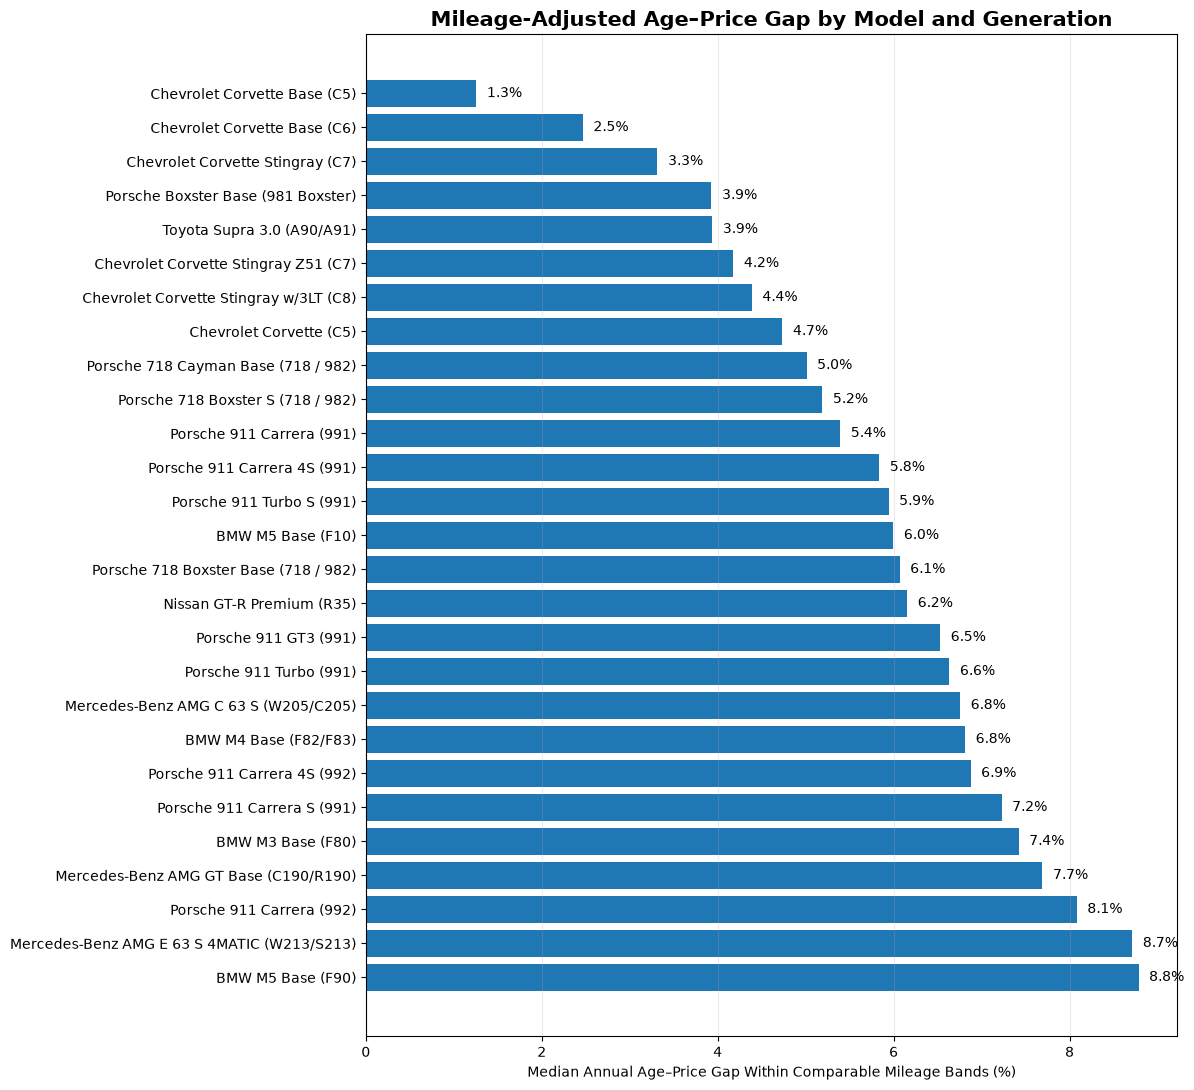

In [55]:
plot_df = (
    retention_summary
    .sort_values(
        "median_annual_age_price_gap_pct",
        ascending=True
    )
    .copy()
)

plot_df["label"] = (
    plot_df["manufacturer"]
    + " "
    + plot_df["model"]
    + " ("
    + plot_df["generation"]
    + ")"
)

fig, ax = plt.subplots(figsize=(12, 11))

ax.barh(
    plot_df["label"],
    plot_df["median_annual_age_price_gap_pct"]
)

ax.invert_yaxis()

ax.set_title(
    "Mileage-Adjusted Age–Price Gap by Model and Generation",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Median Annual Age–Price Gap Within Comparable Mileage Bands (%)"
)
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(
    plot_df["median_annual_age_price_gap_pct"]
):
    ax.text(
        value + 0.12,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "age_price_retention.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [42]:
# Peer-adjusted potential value opportunities
#
# Methodology mirrors SQL:
# - mapped generations only
# - mileage > 0
# - same exact model + generation + year + mileage band
# - at least 5 peer listings
# - peer-group IQR <= 35% of peer median
# - individual listing must not be an IQR price outlier
# - no reported accident/damage
# - no known transmission/drivetrain source inconsistency
# - asking price below peer median

value_df = df[
    (df["generation_quality_flag"] == "Mapped") &
    (df["mileage"] > 0)
].copy()

value_df["mileage_band"] = pd.cut(
    value_df["mileage"],
    bins=[0, 10000, 25000, 50000, 75000, 100000, np.inf],
    labels=[
        "00-09k",
        "10-24k",
        "25-49k",
        "50-74k",
        "75-99k",
        "100k+"
    ],
    right=False
)

peer_cols = [
    "manufacturer",
    "model",
    "generation",
    "year",
    "mileage_band"
]

peer_stats = (
    value_df
    .groupby(peer_cols, observed=True)["price"]
    .agg(
        peer_count="count",
        q1=lambda x: x.quantile(0.25),
        peer_median_price="median",
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

peer_stats["peer_dispersion_pct"] = (
    (peer_stats["q3"] - peer_stats["q1"])
    / peer_stats["peer_median_price"]
    * 100
)

# Same peer-quality requirements as SQL
qualified_peers = peer_stats[
    (peer_stats["peer_count"] >= 5) &
    (peer_stats["peer_dispersion_pct"] <= 35)
].copy()

scored_values = value_df.merge(
    qualified_peers,
    on=peer_cols,
    how="inner"
)

scored_values["lower_bound"] = (
    scored_values["q1"]
    - 1.5 * (scored_values["q3"] - scored_values["q1"])
)

scored_values["upper_bound"] = (
    scored_values["q3"]
    + 1.5 * (scored_values["q3"] - scored_values["q1"])
)

scored_values["price_vs_peer_dollars"] = (
    scored_values["price"]
    - scored_values["peer_median_price"]
)

scored_values["price_vs_peer_pct"] = (
    scored_values["price_vs_peer_dollars"]
    / scored_values["peer_median_price"]
    * 100
)

value_candidates = scored_values[
    (scored_values["price"] >= scored_values["lower_bound"]) &
    (scored_values["price"] <= scored_values["upper_bound"]) &
    (
        scored_values["accident_history"]
        == "No Accident/Damage Reported"
    ) &
    (
        scored_values["transmission_quality_flag"]
        != "Source inconsistency"
    ) &
    (
        scored_values["drivetrain_quality_flag"]
        != "Source inconsistency"
    ) &
    (scored_values["price_vs_peer_pct"] < 0)
].copy()

value_candidates = (
    value_candidates
    .sort_values("price_vs_peer_pct")
    .reset_index(drop=True)
)

value_candidates[
    [
        "source_row_id",
        "manufacturer",
        "model",
        "generation",
        "year",
        "mileage",
        "mileage_band",
        "peer_count",
        "peer_dispersion_pct",
        "price",
        "peer_median_price",
        "price_vs_peer_dollars",
        "price_vs_peer_pct",
        "one_owner_status",
        "transmission_group"
    ]
].head(20)

,source_row_id,manufacturer,model,generation,year,mileage,mileage_band,peer_count,peer_dispersion_pct,price,peer_median_price,price_vs_peer_dollars,price_vs_peer_pct,one_owner_status,transmission_group
0,43184,BMW,M5 Base,F10,2013,"70,918.00",50-74k,11,31.84,"18,900.00","34,500.00","-15,600.00",-45.22,Not One Owner,Automatic
1,517625,Mercedes-Benz,AMG GT C,C190/R190,2020,"21,198.00",10-24k,14,22.26,"82,963.00","130,495.50","-47,532.50",-36.42,One Owner,Automatic
2,517597,Mercedes-Benz,AMG GT C,C190/R190,2020,"24,375.00",10-24k,14,22.26,"82,989.00","130,495.50","-47,506.50",-36.40,One Owner,Automatic
3,616379,Porsche,911,991,2018,"23,434.00",10-24k,11,20.66,"86,997.00","135,995.00","-48,998.00",-36.03,Not One Owner,Automatic
4,517405,Mercedes-Benz,AMG GT C,C190/R190,2020,"13,363.00",10-24k,14,22.26,"86,900.00","130,495.50","-43,595.50",-33.41,One Owner,Automatic
5,609210,Porsche,Boxster S,986 Boxster,2001,"46,747.00",25-49k,6,28.85,"12,888.00","18,955.00","-6,067.00",-32.01,Not One Owner,Automatic
6,617228,Porsche,911 Turbo,997,2007,"14,936.00",10-24k,7,21.55,"87,993.00","127,500.00","-39,507.00",-30.99,Not One Owner,Unknown
7,615135,Porsche,911,991,2018,"24,111.00",10-24k,11,20.66,"94,844.00","135,995.00","-41,151.00",-30.26,Not One Owner,Automatic
8,41916,BMW,M3,E9x,2011,"91,563.00",75-99k,8,16.20,"23,995.00","32,395.00","-8,400.00",-25.93,Not One Owner,Manual
9,617120,Porsche,911,991,2017,"30,086.00",25-49k,11,22.14,"79,991.00","107,900.00","-27,909.00",-25.87,One Owner,Automatic


In [43]:
best_value_by_model = (
    value_candidates
    .sort_values("price_vs_peer_pct")
    .drop_duplicates(
        subset=["manufacturer", "model", "generation"]
    )
    .head(12)
    .copy()
)

best_value_by_model["label"] = (
    best_value_by_model["year"].astype(str)
    + " "
    + best_value_by_model["manufacturer"]
    + " "
    + best_value_by_model["model"]
    + " ("
    + best_value_by_model["generation"]
    + ")"
)

best_value_by_model[
    [
        "label",
        "mileage",
        "price",
        "peer_median_price",
        "peer_count",
        "price_vs_peer_pct"
    ]
]

,label,mileage,price,peer_median_price,peer_count,price_vs_peer_pct
0,2013 BMW M5 Base (F10),"70,918.00","18,900.00","34,500.00",11,-45.22
1,2020 Mercedes-Benz AMG GT C (C190/R190),"21,198.00","82,963.00","130,495.50",14,-36.42
3,2018 Porsche 911 (991),"23,434.00","86,997.00","135,995.00",11,-36.03
5,2001 Porsche Boxster S (986 Boxster),"46,747.00","12,888.00","18,955.00",6,-32.01
6,2007 Porsche 911 Turbo (997),"14,936.00","87,993.00","127,500.00",7,-30.99
8,2011 BMW M3 (E9x),"91,563.00","23,995.00","32,395.00",8,-25.93
12,2002 Chevrolet Corvette Base (C5),"49,051.00","18,999.00","24,950.00",11,-23.85
16,2013 BMW M3 Base (E9x),"58,209.00","29,437.00","37,995.00",5,-22.52
21,2018 BMW M2 Base (F87),"38,686.00","35,955.00","45,901.00",15,-21.67
23,2019 Chevrolet Corvette ZR1 (C7),"9,680.00","168,280.00","209,900.00",16,-19.83


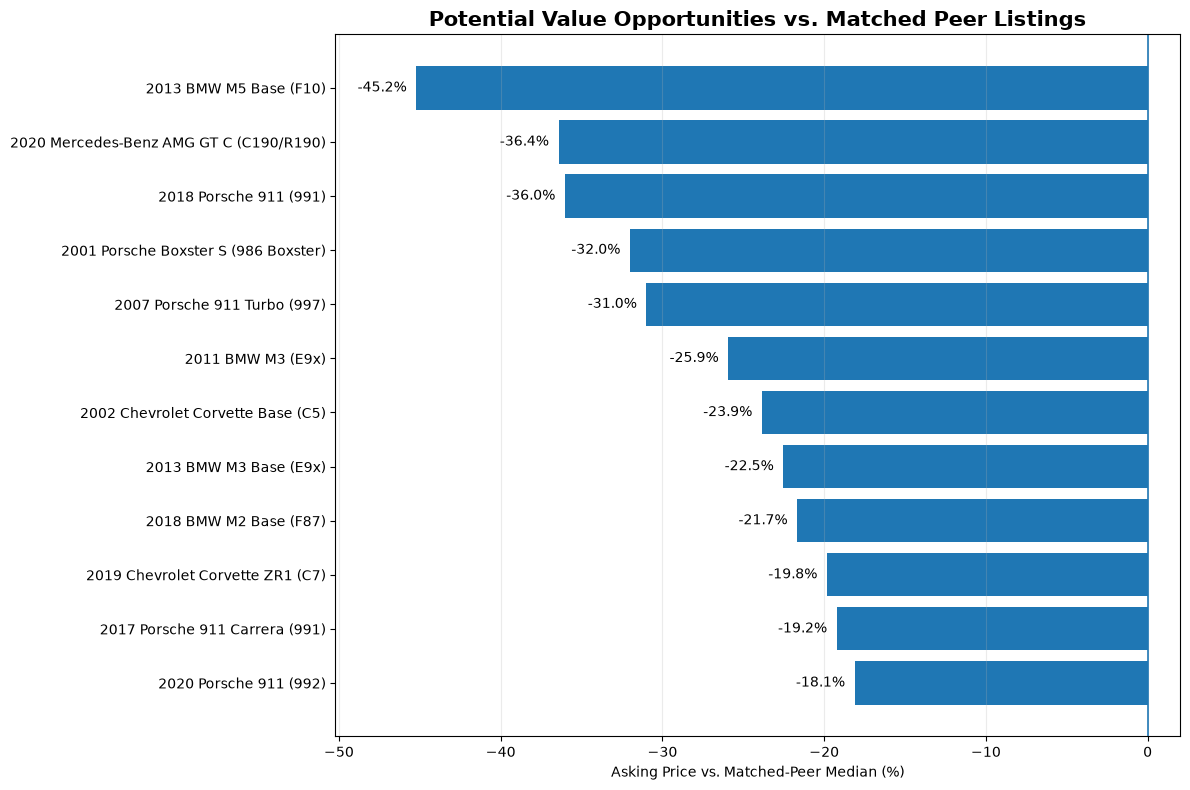

In [57]:
plot_df = (
    best_value_by_model
    .sort_values("price_vs_peer_pct")
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    plot_df["label"],
    plot_df["price_vs_peer_pct"]
)

ax.axvline(
    0,
    linewidth=1.2
)

ax.invert_yaxis()

ax.set_title(
    "Potential Value Opportunities vs. Matched Peer Listings",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Asking Price vs. Matched-Peer Median (%)"
)
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

ax.set_xlim(
    plot_df["price_vs_peer_pct"].min() - 5,
    2
)

for i, value in enumerate(plot_df["price_vs_peer_pct"]):
    ax.text(
        value - 0.6,
        i,
        f"{value:.1f}%",
        va="center",
        ha="right"
    )

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "value_opportunities.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Key Findings

This analysis examined 10,480 enthusiast and performance vehicle listings across eight manufacturers using cleaned marketplace data, matched-peer comparisons, and mileage-adjusted price analysis.

### Market Structure
- Porsche represents the largest share of the dataset, driven heavily by the 911 family.
- Median asking prices vary substantially across the selected enthusiast brands and model families.
- Generation-level pricing is not always linear. For example, the Porsche 996 generation has a substantially lower median asking price than both the preceding 993 and succeeding 997 generations.

### Manual Transmission Premium
Manual transmissions do not command a universal premium.

After comparing listings within the same exact model, generation, model year, and mileage range:
- Porsche 911 Carrera S (991) showed the strongest recurring manual premium among qualified groups.
- Several other enthusiast models showed modest manual premiums.
- Some Corvette and BMW groups showed little premium or even a small manual discount.

This suggests that the market value of a manual transmission is highly model-specific.

### Vehicle History
Accident or damage history showed the clearest systematic relationship with asking price.

Across qualified matched peer groups:
- Accident/damage-reported vehicles showed a median price effect of approximately **-4.0%**.
- One-owner status showed an approximately **+0.4%** median effect.
- Personal-use-only status showed an approximately **-0.7%** median effect.

Accident history therefore appears more strongly associated with asking price than the commonly advertised "one owner" or "personal use only" attributes.

### Age-Price Retention
Age-price relationships were evaluated within comparable mileage ranges using only reliable model-year regressions.

Smaller annual age-price gaps suggest stronger cross-sectional price retention.

Models including the C5/C6 Corvette Base, C7 Stingray, 981 Boxster Base, and A90/A91 Supra 3.0 showed relatively small age-related asking-price gaps.

Models including the F90 M5, W213/S213 E63 S, and 992 Carrera showed substantially larger age-related price differences.

These results represent cross-sectional asking-price relationships and should not be interpreted as observed longitudinal depreciation.

### Potential Value Opportunities
Potential value candidates were identified by comparing each listing with tightly matched peers based on exact model, generation, model year, and mileage range.

Candidates were required to:
- belong to peer groups with at least five listings;
- have limited peer-price dispersion;
- fall within IQR-based price bounds;
- have no reported accident/damage history;
- avoid known drivetrain or transmission source inconsistencies; and
- be priced below the peer median.

These listings should be interpreted as **potential value opportunities**, not confirmed undervalued vehicles, because condition, options, title status, location, and other unobserved factors may influence asking price.

In [45]:
from pathlib import Path

FIGURES_DIR = Path("../docs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(FIGURES_DIR.resolve())

/Users/aniketchristi/Desktop/Apex-Analytics/docs/figures


In [48]:
(FIGURES_DIR / "911_generation_prices.png").exists()

True

In [50]:
(FIGURES_DIR / "manual_transmission_effect.png").exists()

True

In [52]:
(FIGURES_DIR / "accident_history_effect.png").exists()

True

In [54]:
(FIGURES_DIR / "vehicle_history_comparison.png").exists()

True

In [56]:
(FIGURES_DIR / "age_price_retention.png").exists()

True

In [58]:
(FIGURES_DIR / "value_opportunities.png").exists()

True

In [59]:
figure_files = [
    "911_generation_prices.png",
    "manual_transmission_effect.png",
    "accident_history_effect.png",
    "vehicle_history_comparison.png",
    "age_price_retention.png",
    "value_opportunities.png"
]

for file_name in figure_files:
    path = FIGURES_DIR / file_name
    print(f"{file_name}: {path.exists()}")

911_generation_prices.png: True
manual_transmission_effect.png: True
accident_history_effect.png: True
vehicle_history_comparison.png: True
age_price_retention.png: True
value_opportunities.png: True
